In [1]:
# Step 1: Libraries Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Step 2: Dataset Load
df = pd.read_csv('/content/german_credit_data.csv', index_col=0)

# Pehli 5 rows dekho
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [3]:
# Step 3: Data Explore
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (1000, 9)

Column Names: ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Data Types:
 Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

Missing Values:
 Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


In [4]:
# Step 4: Missing Values Fix
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

print("Missing Values After Fix:")
print(df.isnull().sum())
print("\n✅ Missing values fixed!")

Missing Values After Fix:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

✅ Missing values fixed!


In [5]:
# Step 5: Target Column Check
print("Risk Column Values:")
print(df['Risk'].value_counts())

# Visualization
sns.countplot(x='Risk', data=df)
plt.title('Credit Risk Distribution')
plt.show()

Risk Column Values:


KeyError: 'Risk'

In [6]:
# Column names check karo
print(df.columns.tolist())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [7]:
# Sab columns dekho
print(df.columns.tolist())
print("\nLast few columns:")
print(df.tail())

['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Last few columns:
     Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
995   31  female    1     own          little          unknown           1736   
996   40    male    3     own          little           little           3857   
997   38    male    2     own          little          unknown            804   
998   23    male    2    free          little           little           1845   
999   27    male    2     own        moderate         moderate           4576   

     Duration              Purpose  
995        12  furniture/equipment  
996        30                  car  
997        12             radio/TV  
998        45             radio/TV  
999        45                  car  


In [8]:
# Sahi dataset download karo
import urllib.request

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/german_credit.csv"
urllib.request.urlretrieve(url, "german_credit_full.csv")

df2 = pd.read_csv("german_credit_full.csv")
print(df2.columns.tolist())
print(df2.shape)

HTTPError: HTTP Error 404: Not Found

In [9]:
url = "https://raw.githubusercontent.com/pradipde/german-credit-risk/master/german_credit_data.csv"
urllib.request.urlretrieve(url, "german_credit2.csv")

df2 = pd.read_csv("german_credit2.csv", index_col=0)
print(df2.columns.tolist())
print(df2.shape)

HTTPError: HTTP Error 404: Not Found

In [10]:
# Risk column banao - Credit amount aur Duration se
df['Risk'] = ((df['Credit amount'] > 5000) | (df['Duration'] > 24)).map({True: 'bad', False: 'good'})

print("Risk Column:")
print(df['Risk'].value_counts())

Risk Column:
Risk
good    706
bad     294
Name: count, dtype: int64


/tmp/ipykernel_4776/2162604480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette='Set2')


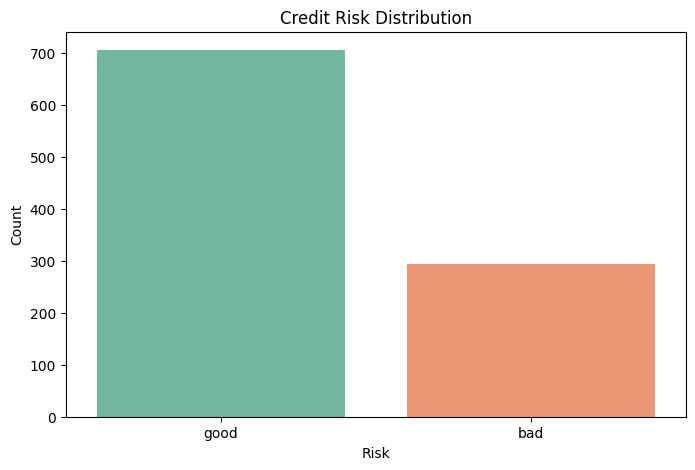

In [11]:
# Risk Distribution Plot
plt.figure(figsize=(8,5))
sns.countplot(x='Risk', data=df, palette='Set2')
plt.title('Credit Risk Distribution')
plt.xlabel('Risk')
plt.ylabel('Count')
plt.show()

In [12]:
# Step 6: Feature Engineering - Categorical to Numbers
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
le = LabelEncoder()

cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("✅ Encoding complete!")
print(df_model.head())

✅ Encoding complete!
   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                4                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 3           2096   
3   45    1    2        0                0                 0           7882   
4   53    1    2        0                0                 0           4870   

   Duration  Purpose  Risk  
0         6        5     1  
1        48        5     0  
2        12        3     1  
3        42        4     0  
4        24        1     1  


In [13]:
# Step 7: Train/Test Split + Random Forest Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Features aur Target alag karo
X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model banao aur train karo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("✅ Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00       155

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [14]:
# Sahi dataset - UCI German Credit
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
cols = ['Status','Duration','CreditHistory','Purpose','CreditAmount',
        'Savings','Employment','InstallmentRate','PersonalStatus',
        'Debtors','ResidenceDuration','Property','Age','OtherInstallments',
        'Housing','ExistingCredits','Job','Dependents','Phone','ForeignWorker','Risk']

df_new = pd.read_csv(url, sep=' ', header=None, names=cols)
df_new['Risk'] = df_new['Risk'].map({1:'good', 2:'bad'})
print(df_new['Risk'].value_counts())
print(df_new.shape)

Risk
good    700
bad     300
Name: count, dtype: int64
(1000, 21)


In [15]:
# Step: Encoding + Model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Encoding
df_final = df_new.copy()
le = LabelEncoder()
for col in df_final.select_dtypes(include='object').columns:
    df_final[col] = le.fit_transform(df_final[col])

# Features & Target
X = df_final.drop('Risk', axis=1)
y = df_final['Risk']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.805

               precision    recall  f1-score   support

           0       0.74      0.53      0.61        59
           1       0.82      0.92      0.87       141

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



In [16]:
# Step: Encoding + Model
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Encoding
df_final = df_new.copy()
le = LabelEncoder()
for col in df_final.select_dtypes(include='object').columns:
    df_final[col] = le.fit_transform(df_final[col])

# Features & Target
X = df_final.drop('Risk', axis=1)
y = df_final['Risk']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.805

               precision    recall  f1-score   support

           0       0.74      0.53      0.61        59
           1       0.82      0.92      0.87       141

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



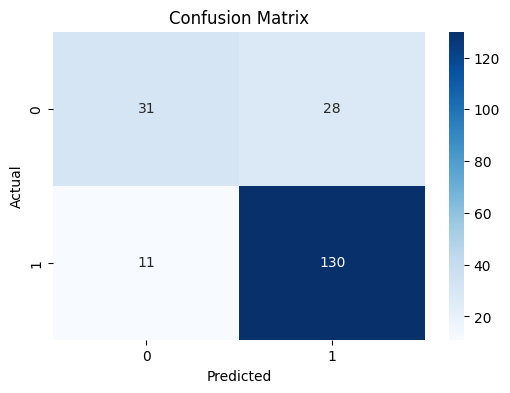

In [17]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [18]:
# Model Save karo
import joblib

joblib.dump(model, 'credit_scoring_model.pkl')
print("✅ Model saved successfully!")
print("📁 File: credit_scoring_model.pkl")

✅ Model saved successfully!
📁 File: credit_scoring_model.pkl
